# Advanced Deep Learning – Homework Lab 3.2


In [1]:
import time
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
from torchvision.datasets import MNIST
from torchvision.transforms import v2


# Reproducibility

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Device

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# Hyperparameters required by assignment

BATCH_SIZE = 256
LR_CAE = 1e-3
LR_HEAD = 1e-3
LR_FINE_TUNE = 1e-4

EPOCHS_CAE = 10
EPOCHS_BATCH_AUG = 100
EPOCHS_CLASSIFIER = 50

NUM_WORKERS = 0


Using device: cuda
GPU: Tesla T4


# Task 3.2.1 — TensorDatasets for MNIST

## 3.2.1(a) Load MNIST and reserve 10,000 random training samples for validation

In [2]:
# Required preprocessing transforms from the assignment
pre_transforms = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize((0.5,), (0.5,))
])

# Load raw MNIST datasets without transforms first.
# The lazy pipeline will apply transforms on the fly.
mnist_train_full = MNIST(root="./data", train=True, download=True)
mnist_test = MNIST(root="./data", train=False, download=True)

# Reserve 10,000 samples for validation
train_size = len(mnist_train_full) - 10_000
val_size = 10_000
train_subset, val_subset = random_split(
    mnist_train_full,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

print("Full training set:", len(mnist_train_full))
print("Training subset:", len(train_subset))
print("Validation subset:", len(val_subset))
print("Test set:", len(mnist_test))


100%|██████████| 9.91M/9.91M [00:01<00:00, 5.60MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 132kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.25MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.97MB/s]

Full training set: 60000
Training subset: 50000
Validation subset: 10000
Test set: 10000


## 3.2.1(b) Lazy DataLoaders with preprocessing applied on the fly

In [3]:
class TransformDataset(torch.utils.data.Dataset):
    """Wraps a dataset/subset and applies transforms lazily in __getitem__."""
    def __init__(self, dataset, transforms=None):
        self.dataset = dataset
        self.transforms = transforms

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        x, y = self.dataset[idx]
        if self.transforms is not None:
            x = self.transforms(x)
        return x, y

lazy_train_ds = TransformDataset(train_subset, transforms=pre_transforms)
lazy_val_ds = TransformDataset(val_subset, transforms=pre_transforms)
lazy_test_ds = TransformDataset(mnist_test, transforms=pre_transforms)

lazy_train_loader = DataLoader(lazy_train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
lazy_val_loader = DataLoader(lazy_val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
lazy_test_loader = DataLoader(lazy_test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# Print shape, dtype, and range of one mini-batch
x_batch, y_batch = next(iter(lazy_train_loader))
print("Lazy mini-batch image shape:", x_batch.shape)
print("Lazy mini-batch label shape:", y_batch.shape)
print("Image dtype:", x_batch.dtype)
print("Label dtype:", y_batch.dtype)
print("Value range:", float(x_batch.min()), "to", float(x_batch.max()))


Lazy mini-batch image shape: torch.Size([256, 1, 28, 28])
Lazy mini-batch label shape: torch.Size([256])
Image dtype: torch.float32
Label dtype: torch.int64
Value range: -1.0 to 1.0


## 3.2.1(c) Convert splits into TensorDatasets with same data and labels

The conversion handles both normal MNIST datasets and `torch.utils.data.Subset` objects created by `random_split`. It also prepends the grayscale channel dimension, applies the required preprocessing, and returns a `TensorDataset`.

In [4]:
def mnist_split_to_tensor_dataset(dataset, transforms=pre_transforms, device=None):
    """Convert MNIST Dataset or Subset into a TensorDataset.

    Expected output image shape: [N, 1, 28, 28]
    Expected dtype after preprocessing: torch.float32
    Expected value range after Normalize((0.5,), (0.5,)): approximately [-1, 1]
    """
    if isinstance(dataset, torch.utils.data.Subset):
        # random_split returns Subset, which stores original dataset and indices.
        raw_data = dataset.dataset.data[dataset.indices]
        raw_labels = dataset.dataset.targets[dataset.indices]
    else:
        raw_data = dataset.data
        raw_labels = dataset.targets

    # raw_data is [N, 28, 28], uint8. Add channel dimension: [N, 1, 28, 28]
    data = raw_data.unsqueeze(1)

    # Apply equivalent preprocessing in batch form:
    # ToDtype(torch.float32, scale=True) => /255.0
    # Normalize((0.5,), (0.5,)) => (x - 0.5) / 0.5
    data = data.to(torch.float32) / 255.0
    data = (data - 0.5) / 0.5
    labels = raw_labels.to(torch.long)

    if device is not None:
        data = data.to(device)
        labels = labels.to(device)

    return TensorDataset(data, labels)

# CPU-resident TensorDatasets
tensor_train_ds_cpu = mnist_split_to_tensor_dataset(train_subset, device=None)
tensor_val_ds_cpu = mnist_split_to_tensor_dataset(val_subset, device=None)
tensor_test_ds_cpu = mnist_split_to_tensor_dataset(mnist_test, device=None)

# GPU-resident TensorDatasets, if CUDA is available
tensor_train_ds_gpu = mnist_split_to_tensor_dataset(train_subset, device=device)
tensor_val_ds_gpu = mnist_split_to_tensor_dataset(val_subset, device=device)
tensor_test_ds_gpu = mnist_split_to_tensor_dataset(mnist_test, device=device)

# Verify shapes, dtypes, and ranges
for name, ds in [
    ("train CPU TensorDataset", tensor_train_ds_cpu),
    ("val CPU TensorDataset", tensor_val_ds_cpu),
    ("test CPU TensorDataset", tensor_test_ds_cpu),
    ("train device TensorDataset", tensor_train_ds_gpu),
]:
    x, y = ds.tensors
    print(f"\n{name}")
    print("images:", x.shape, x.dtype, x.device)
    print("labels:", y.shape, y.dtype, y.device)
    print("value range:", float(x.min().detach().cpu()), "to", float(x.max().detach().cpu()))



train CPU TensorDataset
images: torch.Size([50000, 1, 28, 28]) torch.float32 cpu
labels: torch.Size([50000]) torch.int64 cpu
value range: -1.0 to 1.0

val CPU TensorDataset
images: torch.Size([10000, 1, 28, 28]) torch.float32 cpu
labels: torch.Size([10000]) torch.int64 cpu
value range: -1.0 to 1.0

test CPU TensorDataset
images: torch.Size([10000, 1, 28, 28]) torch.float32 cpu
labels: torch.Size([10000]) torch.int64 cpu
value range: -1.0 to 1.0

train device TensorDataset
images: torch.Size([50000, 1, 28, 28]) torch.float32 cuda:0
labels: torch.Size([50000]) torch.int64 cuda:0
value range: -1.0 to 1.0


In [5]:
tensor_train_loader_cpu = DataLoader(tensor_train_ds_cpu, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
tensor_val_loader_cpu = DataLoader(tensor_val_ds_cpu, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
tensor_test_loader_cpu = DataLoader(tensor_test_ds_cpu, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

tensor_train_loader_gpu = DataLoader(tensor_train_ds_gpu, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
tensor_val_loader_gpu = DataLoader(tensor_val_ds_gpu, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
tensor_test_loader_gpu = DataLoader(tensor_test_ds_gpu, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

x_tensor_batch, y_tensor_batch = next(iter(tensor_train_loader_cpu))
print("TensorDataset mini-batch shape:", x_tensor_batch.shape)
print("TensorDataset mini-batch dtype:", x_tensor_batch.dtype)
print("TensorDataset mini-batch range:", float(x_tensor_batch.min()), "to", float(x_tensor_batch.max()))


TensorDataset mini-batch shape: torch.Size([256, 1, 28, 28])
TensorDataset mini-batch dtype: torch.float32
TensorDataset mini-batch range: -1.0 to 1.0


## 3.2.1(d) Convolutional AutoEncoder with latent dimension 64

In [6]:
class ConvAutoEncoder(nn.Module):
    """Convolutional AutoEncoder for MNIST.

    Encoder output/bottleneck: [batch_size, 64, 1, 1]
    Therefore, the latent dimension is 64.
    """
    def __init__(self, latent_dim=64):
        super().__init__()
        self.latent_dim = latent_dim

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1),  # [B,16,14,14]
            nn.ReLU(inplace=True),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1), # [B,32,7,7]
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1), # [B,64,4,4]
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1))                            # [B,64,1,1]
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, 64, kernel_size=4, stride=1),      # [B,64,4,4]
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1),   # [B,32,7,7]
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1),   # [B,16,14,14]
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(16, 1, kernel_size=4, stride=2, padding=1),    # [B,1,28,28]
            nn.Tanh()  # because images are normalized to [-1, 1]
        )

    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z)
        return out

# Verify bottleneck size
cae_check = ConvAutoEncoder().to(device)
with torch.no_grad():
    sample = x_batch[:4].to(device)
    z = cae_check.encoder(sample)
    recon = cae_check(sample)
print("Encoder bottleneck shape:", z.shape)
print("Reconstruction shape:", recon.shape)


Encoder bottleneck shape: torch.Size([4, 64, 1, 1])
Reconstruction shape: torch.Size([4, 1, 28, 28])


In [7]:
def evaluate_autoencoder(model, loader, criterion, device=device):
    model.eval()
    running_loss = 0.0
    n = 0
    with torch.no_grad():
        for x, _ in loader:
            x = x.to(device, non_blocking=True)
            out = model(x)
            loss = criterion(out, x)
            running_loss += loss.item() * x.size(0)
            n += x.size(0)
    return running_loss / n


def train_autoencoder(model, train_loader, val_loader=None, epochs=10, lr=1e-3, device=device, batch_transform=None, label="CAE"):
    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    history = {"epoch": [], "train_loss": [], "val_loss": [], "epoch_time_sec": []}

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        n = 0
        start = time.perf_counter()

        for x, _ in train_loader:
            x = x.to(device, non_blocking=True)
            if batch_transform is not None:
                x_in = batch_transform(x)
            else:
                x_in = x

            optimizer.zero_grad(set_to_none=True)
            out = model(x_in)
            # The reconstruction target is the original preprocessed image.
            loss = criterion(out, x)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * x.size(0)
            n += x.size(0)

        if torch.cuda.is_available():
            torch.cuda.synchronize()
        epoch_time = time.perf_counter() - start
        train_loss = running_loss / n
        val_loss = evaluate_autoencoder(model, val_loader, criterion, device=device) if val_loader is not None else np.nan

        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["epoch_time_sec"].append(epoch_time)

        print(f"{label} | Epoch {epoch:03d}/{epochs} | train loss: {train_loss:.6f} | val loss: {val_loss:.6f} | time: {epoch_time:.2f}s")

    return model, pd.DataFrame(history)


In [8]:
# Train using lazy DataLoaders for 10 epochs
cae_lazy = ConvAutoEncoder(latent_dim=64)
cae_lazy, hist_cae_lazy = train_autoencoder(
    cae_lazy,
    lazy_train_loader,
    lazy_val_loader,
    epochs=EPOCHS_CAE,
    lr=LR_CAE,
    device=device,
    label="Lazy DataLoader CAE"
)


Lazy DataLoader CAE | Epoch 001/10 | train loss: 0.363291 | val loss: 0.256233 | time: 17.42s
Lazy DataLoader CAE | Epoch 002/10 | train loss: 0.250650 | val loss: 0.241197 | time: 15.66s
Lazy DataLoader CAE | Epoch 003/10 | train loss: 0.214536 | val loss: 0.181577 | time: 16.44s
Lazy DataLoader CAE | Epoch 004/10 | train loss: 0.159550 | val loss: 0.141662 | time: 15.94s
Lazy DataLoader CAE | Epoch 005/10 | train loss: 0.128727 | val loss: 0.119171 | time: 16.40s
Lazy DataLoader CAE | Epoch 006/10 | train loss: 0.110033 | val loss: 0.102085 | time: 15.93s
Lazy DataLoader CAE | Epoch 007/10 | train loss: 0.096464 | val loss: 0.091310 | time: 16.43s
Lazy DataLoader CAE | Epoch 008/10 | train loss: 0.085987 | val loss: 0.081518 | time: 15.83s
Lazy DataLoader CAE | Epoch 009/10 | train loss: 0.078128 | val loss: 0.075046 | time: 16.05s
Lazy DataLoader CAE | Epoch 010/10 | train loss: 0.072379 | val loss: 0.071104 | time: 15.87s


In [9]:

# Train using CPU-resident TensorDataset for 10 epochs
cae_tensor_cpu = ConvAutoEncoder(latent_dim=64)
cae_tensor_cpu, hist_cae_tensor_cpu = train_autoencoder(
    cae_tensor_cpu,
    tensor_train_loader_cpu,
    tensor_val_loader_cpu,
    epochs=EPOCHS_CAE,
    lr=LR_CAE,
    device=device,
    label="CPU TensorDataset CAE"
)


CPU TensorDataset CAE | Epoch 001/10 | train loss: 0.324332 | val loss: 0.249254 | time: 1.38s
CPU TensorDataset CAE | Epoch 002/10 | train loss: 0.236485 | val loss: 0.209276 | time: 1.29s
CPU TensorDataset CAE | Epoch 003/10 | train loss: 0.181986 | val loss: 0.162691 | time: 1.24s
CPU TensorDataset CAE | Epoch 004/10 | train loss: 0.151494 | val loss: 0.139414 | time: 1.05s
CPU TensorDataset CAE | Epoch 005/10 | train loss: 0.128328 | val loss: 0.117509 | time: 1.05s
CPU TensorDataset CAE | Epoch 006/10 | train loss: 0.108973 | val loss: 0.102021 | time: 1.05s
CPU TensorDataset CAE | Epoch 007/10 | train loss: 0.095697 | val loss: 0.090088 | time: 1.07s
CPU TensorDataset CAE | Epoch 008/10 | train loss: 0.085881 | val loss: 0.081824 | time: 1.21s
CPU TensorDataset CAE | Epoch 009/10 | train loss: 0.078944 | val loss: 0.077981 | time: 1.05s
CPU TensorDataset CAE | Epoch 010/10 | train loss: 0.073238 | val loss: 0.071806 | time: 1.05s


In [10]:
# Train using GPU/device-resident TensorDataset for 10 epochs
cae_tensor_gpu = ConvAutoEncoder(latent_dim=64)
cae_tensor_gpu, hist_cae_tensor_gpu = train_autoencoder(
    cae_tensor_gpu,
    tensor_train_loader_gpu,
    tensor_val_loader_gpu,
    epochs=EPOCHS_CAE,
    lr=LR_CAE,
    device=device,
    label="GPU TensorDataset CAE"
)


GPU TensorDataset CAE | Epoch 001/10 | train loss: 0.331696 | val loss: 0.260106 | time: 1.17s
GPU TensorDataset CAE | Epoch 002/10 | train loss: 0.245655 | val loss: 0.222077 | time: 1.04s
GPU TensorDataset CAE | Epoch 003/10 | train loss: 0.194384 | val loss: 0.170274 | time: 1.04s
GPU TensorDataset CAE | Epoch 004/10 | train loss: 0.154605 | val loss: 0.142017 | time: 1.05s
GPU TensorDataset CAE | Epoch 005/10 | train loss: 0.131545 | val loss: 0.122547 | time: 1.51s
GPU TensorDataset CAE | Epoch 006/10 | train loss: 0.113891 | val loss: 0.107387 | time: 1.21s
GPU TensorDataset CAE | Epoch 007/10 | train loss: 0.100169 | val loss: 0.096215 | time: 1.05s
GPU TensorDataset CAE | Epoch 008/10 | train loss: 0.089677 | val loss: 0.086638 | time: 1.05s
GPU TensorDataset CAE | Epoch 009/10 | train loss: 0.082076 | val loss: 0.078538 | time: 1.06s
GPU TensorDataset CAE | Epoch 010/10 | train loss: 0.076155 | val loss: 0.076492 | time: 1.09s


In [11]:
timing_321 = pd.DataFrame({
    "pipeline": ["Lazy DataLoader", "CPU TensorDataset", "GPU/device TensorDataset"],
    "mean_epoch_time_sec": [
        hist_cae_lazy["epoch_time_sec"].mean(),
        hist_cae_tensor_cpu["epoch_time_sec"].mean(),
        hist_cae_tensor_gpu["epoch_time_sec"].mean(),
    ],
    "final_train_loss": [
        hist_cae_lazy["train_loss"].iloc[-1],
        hist_cae_tensor_cpu["train_loss"].iloc[-1],
        hist_cae_tensor_gpu["train_loss"].iloc[-1],
    ],
    "final_val_loss": [
        hist_cae_lazy["val_loss"].iloc[-1],
        hist_cae_tensor_cpu["val_loss"].iloc[-1],
        hist_cae_tensor_gpu["val_loss"].iloc[-1],
    ]
})
timing_321


,pipeline,mean_epoch_time_sec,final_train_loss,final_val_loss
0,Lazy DataLoader,16.199529,0.072379,0.071104
1,CPU TensorDataset,1.144474,0.073238,0.071806
2,GPU/device TensorDataset,1.126344,0.076155,0.076492


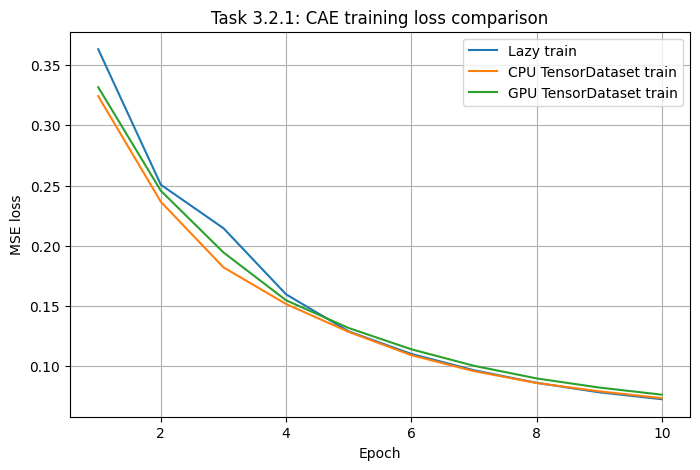

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(hist_cae_lazy["epoch"], hist_cae_lazy["train_loss"], label="Lazy train")
plt.plot(hist_cae_tensor_cpu["epoch"], hist_cae_tensor_cpu["train_loss"], label="CPU TensorDataset train")
plt.plot(hist_cae_tensor_gpu["epoch"], hist_cae_tensor_gpu["train_loss"], label="GPU TensorDataset train")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Task 3.2.1: CAE training loss comparison")
plt.legend()
plt.grid(True)
plt.show()


# Task 3.2.2 — Adding Augmentations

The assignment requires horizontal flip, vertical flip, and random rotation by 10 degrees.

For the **lazy PIL-image pipeline**, rotation happens before normalisation, so a fill value of `0` is suitable because it corresponds to the black MNIST background before scaling.

For the **normalised TensorDataset pipeline**, images are already in `[-1, 1]`, so a fill value of `-1.0` is suitable because it corresponds to the black background after normalisation.

## 3.2.2(a) Lazy DataLoader augmentations and CAE training for 10 epochs

In [13]:
lazy_aug_transforms = v2.Compose([
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomVerticalFlip(p=0.5),
    v2.RandomRotation(10, fill=0),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize((0.5,), (0.5,))
])

lazy_aug_train_ds = TransformDataset(train_subset, transforms=lazy_aug_transforms)
lazy_aug_train_loader = DataLoader(lazy_aug_train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)

x_aug_batch, _ = next(iter(lazy_aug_train_loader))
print("Lazy augmented batch shape:", x_aug_batch.shape)
print("Lazy augmented dtype:", x_aug_batch.dtype)
print("Lazy augmented range:", float(x_aug_batch.min()), "to", float(x_aug_batch.max()))

cae_lazy_aug = ConvAutoEncoder(latent_dim=64)
cae_lazy_aug, hist_cae_lazy_aug = train_autoencoder(
    cae_lazy_aug,
    lazy_aug_train_loader,
    lazy_val_loader,
    epochs=EPOCHS_CAE,
    lr=LR_CAE,
    device=device,
    label="Lazy augmented CAE"
)


Lazy augmented batch shape: torch.Size([256, 1, 28, 28])
Lazy augmented dtype: torch.float32
Lazy augmented range: -1.0 to 1.0
Lazy augmented CAE | Epoch 001/10 | train loss: 0.376043 | val loss: 0.265008 | time: 25.75s
Lazy augmented CAE | Epoch 002/10 | train loss: 0.262294 | val loss: 0.253593 | time: 25.78s
Lazy augmented CAE | Epoch 003/10 | train loss: 0.241021 | val loss: 0.214295 | time: 26.00s
Lazy augmented CAE | Epoch 004/10 | train loss: 0.196499 | val loss: 0.176649 | time: 25.41s
Lazy augmented CAE | Epoch 005/10 | train loss: 0.171682 | val loss: 0.159086 | time: 25.66s
Lazy augmented CAE | Epoch 006/10 | train loss: 0.154283 | val loss: 0.140737 | time: 25.61s
Lazy augmented CAE | Epoch 007/10 | train loss: 0.137606 | val loss: 0.123167 | time: 25.61s
Lazy augmented CAE | Epoch 008/10 | train loss: 0.122359 | val loss: 0.111932 | time: 25.69s
Lazy augmented CAE | Epoch 009/10 | train loss: 0.110928 | val loss: 0.102340 | time: 25.86s
Lazy augmented CAE | Epoch 010/10 | 

In [14]:
loss_compare_lazy_aug = pd.DataFrame({
    "model": ["No augmentation, lazy", "With augmentation, lazy"],
    "final_train_loss": [hist_cae_lazy["train_loss"].iloc[-1], hist_cae_lazy_aug["train_loss"].iloc[-1]],
    "final_val_loss": [hist_cae_lazy["val_loss"].iloc[-1], hist_cae_lazy_aug["val_loss"].iloc[-1]],
    "mean_epoch_time_sec": [hist_cae_lazy["epoch_time_sec"].mean(), hist_cae_lazy_aug["epoch_time_sec"].mean()]
})
loss_compare_lazy_aug


,model,final_train_loss,final_val_loss,mean_epoch_time_sec
0,"No augmentation, lazy",0.072379,0.071104,16.199529
1,"With augmentation, lazy",0.102174,0.093095,25.663318


## 3.2.2(b) TensorDataset augmentations using a custom AugmentedTensorDataset

In [ ]:
class AugmentedTensorDataset(torch.utils.data.Dataset):
    """Wrap a TensorDataset and apply transforms per sample."""
    def __init__(self, tensor_dataset, transforms=None):
        self.tensor_dataset = tensor_dataset
        self.transforms = transforms

    def __len__(self):
        return len(self.tensor_dataset)

    def __getitem__(self, idx):
        data, label = self.tensor_dataset[idx]
        if self.transforms:
            data = self.transforms(data)
        return data, label

# For already-normalized tensors, fill=-1.0 corresponds to the black MNIST background.
tensor_aug_transforms = v2.Compose([
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomVerticalFlip(p=0.5),
    v2.RandomRotation(10, fill=-1.0),
])

aug_tensor_train_ds_cpu = AugmentedTensorDataset(tensor_train_ds_cpu, transforms=tensor_aug_transforms)
aug_tensor_train_loader_cpu = DataLoader(aug_tensor_train_ds_cpu, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)

x_aug_tensor_batch, _ = next(iter(aug_tensor_train_loader_cpu))
print("Augmented TensorDataset batch shape:", x_aug_tensor_batch.shape)
print("Augmented TensorDataset dtype:", x_aug_tensor_batch.dtype)
print("Augmented TensorDataset range:", float(x_aug_tensor_batch.min()), "to", float(x_aug_tensor_batch.max()))

cae_tensor_aug = ConvAutoEncoder(latent_dim=64)
cae_tensor_aug, hist_cae_tensor_aug = train_autoencoder(
    cae_tensor_aug,
    aug_tensor_train_loader_cpu,
    tensor_val_loader_cpu,
    epochs=EPOCHS_CAE,
    lr=LR_CAE,
    device=device,
    label="Per-sample TensorDataset augmented CAE"
)


Augmented TensorDataset batch shape: torch.Size([256, 1, 28, 28])
Augmented TensorDataset dtype: torch.float32
Augmented TensorDataset range: -1.0 to 1.0
Per-sample TensorDataset augmented CAE | Epoch 001/10 | train loss: 0.362668 | val loss: 0.261798 | time: 32.72s
Per-sample TensorDataset augmented CAE | Epoch 002/10 | train loss: 0.254868 | val loss: 0.240636 | time: 26.37s
Per-sample TensorDataset augmented CAE | Epoch 003/10 | train loss: 0.215544 | val loss: 0.191324 | time: 26.28s
Per-sample TensorDataset augmented CAE | Epoch 004/10 | train loss: 0.182663 | val loss: 0.167915 | time: 26.94s
Per-sample TensorDataset augmented CAE | Epoch 005/10 | train loss: 0.159868 | val loss: 0.144309 | time: 26.34s
Per-sample TensorDataset augmented CAE | Epoch 006/10 | train loss: 0.140142 | val loss: 0.126142 | time: 25.85s
Per-sample TensorDataset augmented CAE | Epoch 007/10 | train loss: 0.124581 | val loss: 0.112529 | time: 26.18s


## 3.2.2(c) GPU batch augmentations and CAE training for 100 epochs

In [ ]:
# Batch augmentation can be applied directly to a whole GPU batch inside the training loop.
# These transforms operate on [B, C, H, W] tensors.
gpu_batch_aug_transforms = v2.Compose([
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomVerticalFlip(p=0.5),
    v2.RandomRotation(10, fill=-1.0),
])

def gpu_batch_transform(x):
    return gpu_batch_aug_transforms(x)

cae_batch_aug = ConvAutoEncoder(latent_dim=64)
cae_batch_aug, hist_cae_batch_aug = train_autoencoder(
    cae_batch_aug,
    tensor_train_loader_gpu,
    tensor_val_loader_gpu,
    epochs=EPOCHS_BATCH_AUG,
    lr=LR_CAE,
    device=device,
    batch_transform=gpu_batch_transform,
    label="GPU batch augmented CAE"
)


GPU batch augmented CAE | Epoch 001/100 | train loss: 0.419878 | val loss: 0.252369 | time: 1.44s
GPU batch augmented CAE | Epoch 002/100 | train loss: 0.241959 | val loss: 0.228315 | time: 1.17s
GPU batch augmented CAE | Epoch 003/100 | train loss: 0.221778 | val loss: 0.215651 | time: 1.22s
GPU batch augmented CAE | Epoch 004/100 | train loss: 0.211757 | val loss: 0.207616 | time: 1.49s
GPU batch augmented CAE | Epoch 005/100 | train loss: 0.204777 | val loss: 0.198090 | time: 1.28s
GPU batch augmented CAE | Epoch 006/100 | train loss: 0.196829 | val loss: 0.189498 | time: 1.19s
GPU batch augmented CAE | Epoch 007/100 | train loss: 0.190800 | val loss: 0.183057 | time: 1.34s
GPU batch augmented CAE | Epoch 008/100 | train loss: 0.185397 | val loss: 0.174426 | time: 1.20s
GPU batch augmented CAE | Epoch 009/100 | train loss: 0.180765 | val loss: 0.171921 | time: 1.19s
GPU batch augmented CAE | Epoch 010/100 | train loss: 0.176805 | val loss: 0.164491 | time: 1.20s
GPU batch augmented 

In [17]:
summary_322 = pd.DataFrame({
    "setting": [
        "No augmentation lazy, 10 epochs",
        "Lazy augmentation, 10 epochs",
        "Per-sample TensorDataset augmentation, 10 epochs",
        "GPU batch augmentation, 100 epochs"
    ],
    "final_train_loss": [
        hist_cae_lazy["train_loss"].iloc[-1],
        hist_cae_lazy_aug["train_loss"].iloc[-1],
        hist_cae_tensor_aug["train_loss"].iloc[-1],
        hist_cae_batch_aug["train_loss"].iloc[-1]
    ],
    "final_val_loss": [
        hist_cae_lazy["val_loss"].iloc[-1],
        hist_cae_lazy_aug["val_loss"].iloc[-1],
        hist_cae_tensor_aug["val_loss"].iloc[-1],
        hist_cae_batch_aug["val_loss"].iloc[-1]
    ],
    "mean_epoch_time_sec": [
        hist_cae_lazy["epoch_time_sec"].mean(),
        hist_cae_lazy_aug["epoch_time_sec"].mean(),
        hist_cae_tensor_aug["epoch_time_sec"].mean(),
        hist_cae_batch_aug["epoch_time_sec"].mean()
    ]
})
summary_322


,setting,final_train_loss,final_val_loss,mean_epoch_time_sec
0,"No augmentation lazy, 10 epochs",0.072379,0.071104,16.199529
1,"Lazy augmentation, 10 epochs",0.102174,0.093095,25.663318
2,"Per-sample TensorDataset augmentation, 10 epochs",0.096011,0.086464,26.919112
3,"GPU batch augmentation, 100 epochs",0.100981,0.094412,1.256793


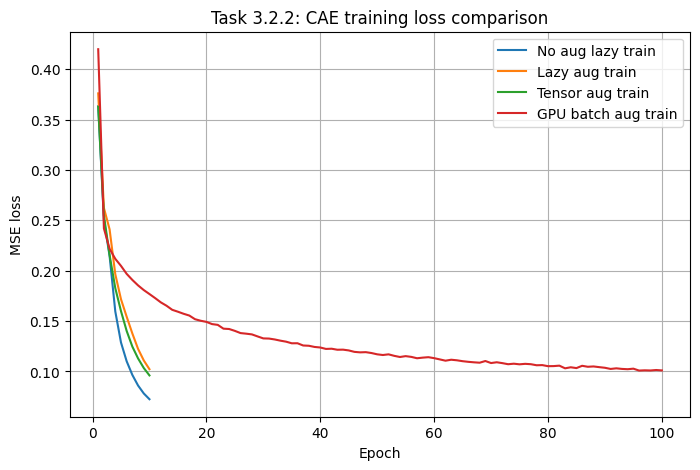

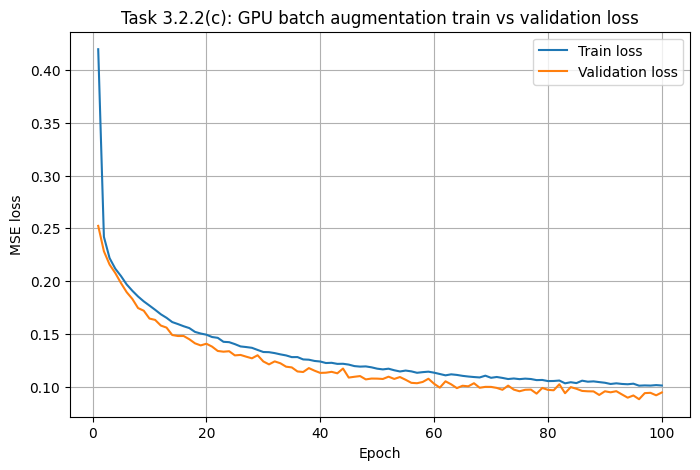

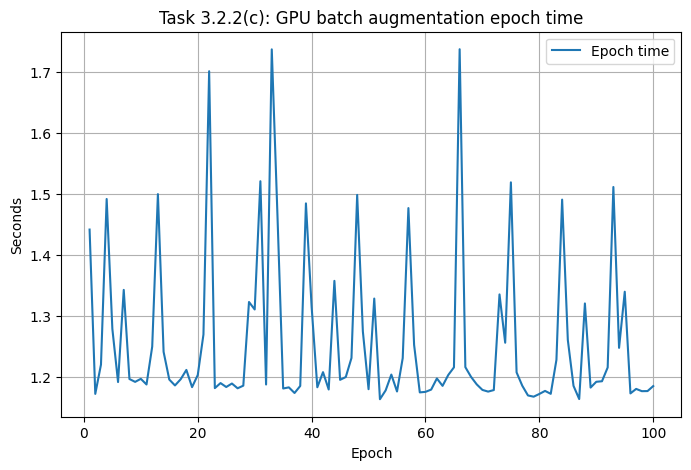

In [18]:
plt.figure(figsize=(8, 5))
plt.plot(hist_cae_lazy["epoch"], hist_cae_lazy["train_loss"], label="No aug lazy train")
plt.plot(hist_cae_lazy_aug["epoch"], hist_cae_lazy_aug["train_loss"], label="Lazy aug train")
plt.plot(hist_cae_tensor_aug["epoch"], hist_cae_tensor_aug["train_loss"], label="Tensor aug train")
plt.plot(hist_cae_batch_aug["epoch"], hist_cae_batch_aug["train_loss"], label="GPU batch aug train")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Task 3.2.2: CAE training loss comparison")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(hist_cae_batch_aug["epoch"], hist_cae_batch_aug["train_loss"], label="Train loss")
plt.plot(hist_cae_batch_aug["epoch"], hist_cae_batch_aug["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Task 3.2.2(c): GPU batch augmentation train vs validation loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(hist_cae_batch_aug["epoch"], hist_cae_batch_aug["epoch_time_sec"], label="Epoch time")
plt.xlabel("Epoch")
plt.ylabel("Seconds")
plt.title("Task 3.2.2(c): GPU batch augmentation epoch time")
plt.legend()
plt.grid(True)
plt.show()


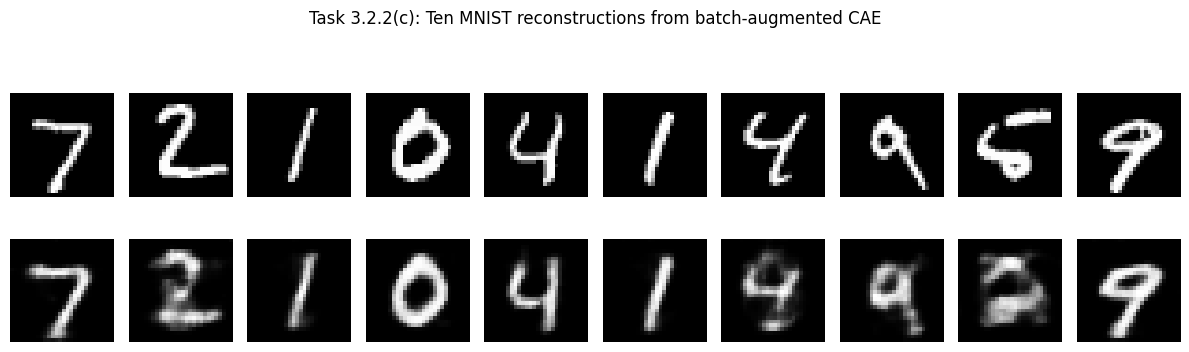

In [19]:
# Plot ten reconstructions of the CAE trained with batch augmentations
cae_batch_aug.eval()
images, labels = next(iter(tensor_test_loader_gpu))
images = images[:10].to(device)
with torch.no_grad():
    reconstructions = cae_batch_aug(images)

# Denormalize from [-1, 1] to [0, 1] for display
def denormalize_mnist(x):
    return (x * 0.5 + 0.5).clamp(0, 1)

orig = denormalize_mnist(images.detach().cpu())
recon = denormalize_mnist(reconstructions.detach().cpu())

plt.figure(figsize=(12, 4))
for i in range(10):
    plt.subplot(2, 10, i + 1)
    plt.imshow(orig[i, 0], cmap="gray")
    plt.axis("off")
    if i == 0:
        plt.ylabel("Original")

    plt.subplot(2, 10, i + 11)
    plt.imshow(recon[i, 0], cmap="gray")
    plt.axis("off")
    if i == 0:
        plt.ylabel("Recon")

plt.suptitle("Task 3.2.2(c): Ten MNIST reconstructions from batch-augmented CAE")
plt.tight_layout()
plt.show()


# Task 3.2.3 — Pre-Trained Encoder for Classification

The encoder trained in Task 3.2.2(c) is reused as a feature extractor. The decoder is discarded and a small classification head for the 10 MNIST classes is added.

Three settings are compared:

1. **Frozen pretrained encoder** — train only the classification head.
2. **Fine-tuned pretrained encoder** — unfreeze encoder and train the complete classifier with a smaller learning rate.
3. **Randomly initialized encoder** — same architecture trained from scratch.

In [20]:
class EncoderClassifier(nn.Module):
    def __init__(self, encoder, num_classes=10):
        super().__init__()
        self.encoder = encoder
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.2),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        z = self.encoder(x)
        logits = self.classifier(z)
        return logits


def set_encoder_trainable(model, trainable: bool):
    for p in model.encoder.parameters():
        p.requires_grad = trainable


def evaluate_classifier(model, loader, criterion, device=device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            logits = model(x)
            loss = criterion(logits, y)
            total_loss += loss.item() * x.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    return total_loss / total, correct / total


def train_classifier(model, train_loader, val_loader, epochs, lr, device=device, label="classifier"):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    history = {"epoch": [], "train_loss": [], "val_loss": [], "val_acc": [], "epoch_time_sec": []}

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        total = 0
        start = time.perf_counter()

        for x, y in train_loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * x.size(0)
            total += y.size(0)

        if torch.cuda.is_available():
            torch.cuda.synchronize()
        epoch_time = time.perf_counter() - start
        train_loss = total_loss / total
        val_loss, val_acc = evaluate_classifier(model, val_loader, criterion, device=device)

        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["epoch_time_sec"].append(epoch_time)

        print(f"{label} | Epoch {epoch:03d}/{epochs} | train loss: {train_loss:.4f} | val loss: {val_loss:.4f} | val acc: {val_acc:.4f} | time: {epoch_time:.2f}s")

    return model, pd.DataFrame(history)


## 3.2.3(a) Freeze the pretrained encoder and train only the classification head

In [21]:
# Use a deepcopy to avoid side effects on the original CAE model, as required.
encoder_copy_frozen = copy.deepcopy(cae_batch_aug.encoder.to("cpu"))
classifier_frozen = EncoderClassifier(encoder_copy_frozen, num_classes=10)
set_encoder_trainable(classifier_frozen, trainable=False)

classifier_frozen, hist_cls_frozen = train_classifier(
    classifier_frozen,
    tensor_train_loader_gpu,
    tensor_val_loader_gpu,
    epochs=EPOCHS_CLASSIFIER,
    lr=LR_HEAD,
    device=device,
    label="Frozen pretrained encoder"
)

criterion_cls = nn.CrossEntropyLoss()
frozen_test_loss, frozen_test_acc = evaluate_classifier(classifier_frozen, tensor_test_loader_gpu, criterion_cls, device=device)
print("Frozen pretrained encoder test loss:", frozen_test_loss)
print("Frozen pretrained encoder test accuracy:", frozen_test_acc)


Frozen pretrained encoder | Epoch 001/50 | train loss: 1.3559 | val loss: 0.7445 | val acc: 0.8128 | time: 1.98s
Frozen pretrained encoder | Epoch 002/50 | train loss: 0.6475 | val loss: 0.4797 | val acc: 0.8699 | time: 0.71s
Frozen pretrained encoder | Epoch 003/50 | train loss: 0.4872 | val loss: 0.3930 | val acc: 0.8881 | time: 0.73s
Frozen pretrained encoder | Epoch 004/50 | train loss: 0.4186 | val loss: 0.3502 | val acc: 0.8955 | time: 0.69s
Frozen pretrained encoder | Epoch 005/50 | train loss: 0.3802 | val loss: 0.3216 | val acc: 0.9021 | time: 0.71s
Frozen pretrained encoder | Epoch 006/50 | train loss: 0.3542 | val loss: 0.3034 | val acc: 0.9077 | time: 0.69s
Frozen pretrained encoder | Epoch 007/50 | train loss: 0.3378 | val loss: 0.2864 | val acc: 0.9111 | time: 0.69s
Frozen pretrained encoder | Epoch 008/50 | train loss: 0.3197 | val loss: 0.2740 | val acc: 0.9152 | time: 0.88s
Frozen pretrained encoder | Epoch 009/50 | train loss: 0.3090 | val loss: 0.2630 | val acc: 0.91

## 3.2.3(b) Unfreeze the pretrained encoder and fine-tune with a smaller learning rate

In [22]:
encoder_copy_finetune = copy.deepcopy(cae_batch_aug.encoder.to("cpu"))
classifier_finetune = EncoderClassifier(encoder_copy_finetune, num_classes=10)
set_encoder_trainable(classifier_finetune, trainable=True)

classifier_finetune, hist_cls_finetune = train_classifier(
    classifier_finetune,
    tensor_train_loader_gpu,
    tensor_val_loader_gpu,
    epochs=EPOCHS_CLASSIFIER,
    lr=LR_FINE_TUNE,
    device=device,
    label="Fine-tuned pretrained encoder"
)

finetune_test_loss, finetune_test_acc = evaluate_classifier(classifier_finetune, tensor_test_loader_gpu, criterion_cls, device=device)
print("Fine-tuned pretrained encoder test loss:", finetune_test_loss)
print("Fine-tuned pretrained encoder test accuracy:", finetune_test_acc)


Fine-tuned pretrained encoder | Epoch 001/50 | train loss: 2.0304 | val loss: 1.5913 | val acc: 0.6147 | time: 0.90s
Fine-tuned pretrained encoder | Epoch 002/50 | train loss: 1.3150 | val loss: 0.9768 | val acc: 0.7551 | time: 1.28s
Fine-tuned pretrained encoder | Epoch 003/50 | train loss: 0.9050 | val loss: 0.6925 | val acc: 0.8205 | time: 1.17s
Fine-tuned pretrained encoder | Epoch 004/50 | train loss: 0.6986 | val loss: 0.5501 | val acc: 0.8554 | time: 0.88s
Fine-tuned pretrained encoder | Epoch 005/50 | train loss: 0.5790 | val loss: 0.4636 | val acc: 0.8764 | time: 0.87s
Fine-tuned pretrained encoder | Epoch 006/50 | train loss: 0.5015 | val loss: 0.4044 | val acc: 0.8885 | time: 0.87s
Fine-tuned pretrained encoder | Epoch 007/50 | train loss: 0.4435 | val loss: 0.3657 | val acc: 0.8967 | time: 0.88s
Fine-tuned pretrained encoder | Epoch 008/50 | train loss: 0.4052 | val loss: 0.3315 | val acc: 0.9049 | time: 0.86s
Fine-tuned pretrained encoder | Epoch 009/50 | train loss: 0.371

## 3.2.3(c) Train the same classifier architecture from scratch

In [23]:
random_encoder = ConvAutoEncoder(latent_dim=64).encoder
classifier_random = EncoderClassifier(random_encoder, num_classes=10)
set_encoder_trainable(classifier_random, trainable=True)

classifier_random, hist_cls_random = train_classifier(
    classifier_random,
    tensor_train_loader_gpu,
    tensor_val_loader_gpu,
    epochs=EPOCHS_CLASSIFIER,
    lr=LR_HEAD,
    device=device,
    label="Randomly initialized encoder"
)

random_test_loss, random_test_acc = evaluate_classifier(classifier_random, tensor_test_loader_gpu, criterion_cls, device=device)
print("Random initialization test loss:", random_test_loss)
print("Random initialization test accuracy:", random_test_acc)


Randomly initialized encoder | Epoch 001/50 | train loss: 1.6671 | val loss: 1.0398 | val acc: 0.6615 | time: 0.91s
Randomly initialized encoder | Epoch 002/50 | train loss: 0.8498 | val loss: 0.5836 | val acc: 0.8163 | time: 0.88s
Randomly initialized encoder | Epoch 003/50 | train loss: 0.5272 | val loss: 0.4060 | val acc: 0.8764 | time: 0.86s
Randomly initialized encoder | Epoch 004/50 | train loss: 0.3921 | val loss: 0.2862 | val acc: 0.9146 | time: 1.02s
Randomly initialized encoder | Epoch 005/50 | train loss: 0.3159 | val loss: 0.2644 | val acc: 0.9208 | time: 0.86s
Randomly initialized encoder | Epoch 006/50 | train loss: 0.2735 | val loss: 0.2268 | val acc: 0.9312 | time: 1.07s
Randomly initialized encoder | Epoch 007/50 | train loss: 0.2416 | val loss: 0.2004 | val acc: 0.9384 | time: 1.19s
Randomly initialized encoder | Epoch 008/50 | train loss: 0.2206 | val loss: 0.1824 | val acc: 0.9451 | time: 0.91s
Randomly initialized encoder | Epoch 009/50 | train loss: 0.1970 | val l

## 3.2.3(d) Plot loss curves and compare all three settings in one table

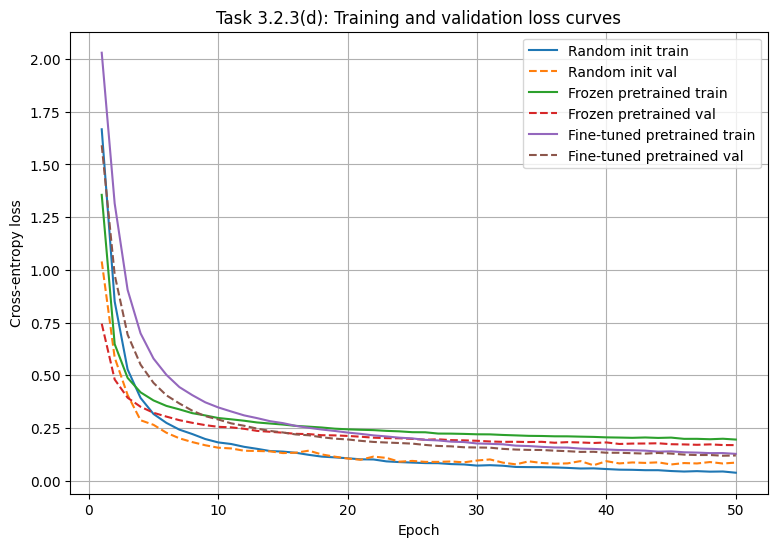

In [24]:
plt.figure(figsize=(9, 6))
plt.plot(hist_cls_random["epoch"], hist_cls_random["train_loss"], label="Random init train")
plt.plot(hist_cls_random["epoch"], hist_cls_random["val_loss"], linestyle="--", label="Random init val")
plt.plot(hist_cls_frozen["epoch"], hist_cls_frozen["train_loss"], label="Frozen pretrained train")
plt.plot(hist_cls_frozen["epoch"], hist_cls_frozen["val_loss"], linestyle="--", label="Frozen pretrained val")
plt.plot(hist_cls_finetune["epoch"], hist_cls_finetune["train_loss"], label="Fine-tuned pretrained train")
plt.plot(hist_cls_finetune["epoch"], hist_cls_finetune["val_loss"], linestyle="--", label="Fine-tuned pretrained val")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("Task 3.2.3(d): Training and validation loss curves")
plt.legend()
plt.grid(True)
plt.show()


In [25]:
comparison_323 = pd.DataFrame({
    "setting": [
        "random initialization",
        "frozen pretrained encoder",
        "fine-tuned pretrained encoder"
    ],
    "encoder_trainable": [True, False, True],
    "learning_rate": [LR_HEAD, LR_HEAD, LR_FINE_TUNE],
    "final_train_loss": [
        hist_cls_random["train_loss"].iloc[-1],
        hist_cls_frozen["train_loss"].iloc[-1],
        hist_cls_finetune["train_loss"].iloc[-1]
    ],
    "final_val_loss": [
        hist_cls_random["val_loss"].iloc[-1],
        hist_cls_frozen["val_loss"].iloc[-1],
        hist_cls_finetune["val_loss"].iloc[-1]
    ],
    "final_val_accuracy": [
        hist_cls_random["val_acc"].iloc[-1],
        hist_cls_frozen["val_acc"].iloc[-1],
        hist_cls_finetune["val_acc"].iloc[-1]
    ],
    "test_loss": [random_test_loss, frozen_test_loss, finetune_test_loss],
    "test_accuracy": [random_test_acc, frozen_test_acc, finetune_test_acc],
    "mean_epoch_time_sec": [
        hist_cls_random["epoch_time_sec"].mean(),
        hist_cls_frozen["epoch_time_sec"].mean(),
        hist_cls_finetune["epoch_time_sec"].mean()
    ]
})
comparison_323


,setting,encoder_trainable,learning_rate,final_train_loss,final_val_loss,final_val_accuracy,test_loss,test_accuracy,mean_epoch_time_sec
0,random initialization,True,0.0010,0.037076,0.085026,0.9767,0.072264,0.9798,0.919412
1,frozen pretrained encoder,False,0.0010,0.194459,0.168058,0.9468,0.166799,0.9474,0.776431
2,fine-tuned pretrained encoder,True,0.0001,0.126545,0.118911,0.9632,0.105569,0.9675,0.929960
